In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure # Para CLAHE en color

In [2]:
# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Funciones Auxiliares para Mostrar Imágenes ---
def mostrar_imagen(titulo, imagen, cmap=None):
    plt.figure(figsize=(8, 6))
    if cmap:
        plt.imshow(imagen, cmap=cmap)
    else:
        # OpenCV carga en BGR, Matplotlib espera RGB
        plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

def mostrar_histograma(imagen, titulo="Histograma"):
    if len(imagen.shape) == 3: # Imagen a color
        color = ('b', 'g', 'r')
        for i, col in enumerate(color):
            hist = cv2.calcHist([imagen], [i], None, [256], [0, 256])
            plt.plot(hist, color=col)
        plt.title(f"{titulo} (RGB)")
    else: # Imagen en escala de grises
        hist = cv2.calcHist([imagen], [0], None, [256], [0, 256])
        plt.plot(hist, color='gray')
        plt.title(f"{titulo} (Escala de Grises)")
    plt.xlim([0, 256])
    plt.show()

def show_images(images, titles=None):
    """Display multiple images in a grid."""
    n = len(images)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i in range(n):
        image = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        axes[i].imshow(image)
        if titles:
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    
    for j in range(i + 1, rows * cols):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    

# ------- Funciones para alteracion del color y umbralizacion -------------

def filtro_gris(img, mask, uint8=True):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h1, w1 = img.shape
    h2, w2 = mask.shape
    
    g = np.zeros_like(img, dtype=np.float32)
    for y in range(w1):
        for x in range(h1):
            valor = 0
            s = -h2 // 2
            for j in range(w2):
                t = -w2 // 2
                for i in range(h2):
                    if 0 <= y+t < w1 and 0 <= x+s < h1:
                        valor += mask[i, j] * img[x+s, y+t]
                    t += 1
                s += 1
            g[x, y] = valor
    if uint8:
        return np.clip(g, 0, 255).astype(np.uint8)
    else:
        return np.clip(g, 0, 255)

def ecualizar_histograma(imagen):
    if len(imagen.shape) == 3:  # Imagen a color
        canales = cv2.split(imagen)
        canales_ecualizados = [cv2.equalizeHist(canal) for canal in canales]
        imagen_ecualizada = cv2.merge(canales_ecualizados)
    else:  # Imagen en escala de grises
        imagen_ecualizada = cv2.equalizeHist(imagen)
    
    return imagen_ecualizada

def clahe_color(imagen, clip_limit=2.0, tile_grid_size=(8, 8)):
    if len(imagen.shape) == 3:  # Imagen a color
        canales = cv2.split(imagen)
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        canales_clahe = [clahe.apply(canal) for canal in canales]
        imagen_clahe = cv2.merge(canales_clahe)
    else:  # Imagen en escala de grises
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
        imagen_clahe = clahe.apply(imagen)
    
    return imagen_clahe

def umbralizacion(imagen, umbral=127, metodo=cv2.THRESH_BINARY):
    if len(imagen.shape) == 3:  # Imagen a color
        imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    else:  # Imagen en escala de grises
        imagen_gris = imagen
    
    _, imagen_umbralizada = cv2.threshold(imagen_gris, umbral, 255, metodo)
    
    return imagen_umbralizada

def umbralizacion_adaptativa(imagen, metodo=cv2.ADAPTIVE_THRESH_MEAN_C, tipo=cv2.THRESH_BINARY, bloque_size=11, constante=2):
    if len(imagen.shape) == 3:  # Imagen a color
        imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    else:  # Imagen en escala de grises
        imagen_gris = imagen
    
    imagen_umbralizada = cv2.adaptiveThreshold(imagen_gris, 255, metodo, tipo, bloque_size, constante)
    
    return imagen_umbralizada

# --------- Funciones de Filtrado Espacial -------------------
def filtro_media(imagen, kernel_size=(5, 5)):
    kernel = np.ones(kernel_size, np.float32) / (kernel_size[0] * kernel_size[1])
    imagen_filtrada = cv2.filter2D(imagen, -1, kernel)
    return imagen_filtrada

def filtro_gaussiano(imagen, kernel_size=(5, 5), sigma=0):
    imagen_filtrada = cv2.GaussianBlur(imagen, kernel_size, sigma)
    return imagen_filtrada

def filtro_mediana(imagen, kernel_size=5):
    imagen_filtrada = cv2.medianBlur(imagen, kernel_size)
    return imagen_filtrada

def filtro_mediana_selectivo(img_ruidosa, kernel_size=3):
    img_filtrada = img_ruidosa.copy()

    # Detectar ruido (simplificado para 8-bit)
    mascara_sal = (img_ruidosa == 255)
    mascara_pimienta = (img_ruidosa == 0)
    mascara_ruido = np.logical_or(mascara_sal, mascara_pimienta)

    # Aplicar filtro de mediana solo a una copia temporal
    img_median_temp = cv2.medianBlur(img_ruidosa, kernel_size)

    # Reemplazar solo los píxeles ruidosos
    img_filtrada[mascara_ruido] = img_median_temp[mascara_ruido]
    return img_filtrada

def filtro_laplaciano(imagen, kernel_size=(3, 3)):
    kernel = cv2.getDerivKernels(1, 1, ksize=kernel_size[0], normalize=True)
    laplacian = cv2.filter2D(imagen, -1, kernel[0] * kernel[1])
    return laplacian

def filtro_sobel(imagen, dx=1, dy=1, kernel_size=3):
    sobel_x = cv2.Sobel(imagen, cv2.CV_64F, dx, 0, ksize=kernel_size)
    sobel_y = cv2.Sobel(imagen, cv2.CV_64F, 0, dy, ksize=kernel_size)
    sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)
    return np.uint8(sobel_combined)

def filtro_prewitt(imagen):
    kernel_prewitt_x = np.array([[1, 0, -1],
                                  [1, 0, -1],
                                  [1, 0, -1]], dtype=np.float32)
    
    kernel_prewitt_y = np.array([[1, 1, 1],
                                  [0, 0, 0],
                                  [-1, -1, -1]], dtype=np.float32)
    
    prewitt_x = cv2.filter2D(imagen, -1, kernel_prewitt_x)
    prewitt_y = cv2.filter2D(imagen, -1, kernel_prewitt_y)
    prewitt_combined = np.sqrt(prewitt_x**2 + prewitt_y**2)
    
    return np.uint8(prewitt_combined)

def cruzado_de_roberts(imagen): 
    kernel_roberts_x = np.array([[1, 0],
                                  [0, -1]], dtype=np.float32)
    
    kernel_roberts_y = np.array([[0, 1],
                                  [-1, 0]], dtype=np.float32)
    
    roberts_x = cv2.filter2D(imagen, -1, kernel_roberts_x)
    roberts_y = cv2.filter2D(imagen, -1, kernel_roberts_y)
    roberts_combined = np.sqrt(roberts_x**2 + roberts_y**2)
    
    return np.uint8(roberts_combined)

 #Filtro Non-Local Means (NL-Means):
def filtro_non_local_means(imagen, h=10, templateWindowSize=7, searchWindowSize=21):
    """
    Aplica el filtro Non-Local Means (NL-Means) a una imagen.
    
    Args:
        imagen (np.ndarray): Imagen de entrada (grayscale o color).
        h (float): Parámetro de suavizado. Valores más altos resultan en mayor suavizado.
        templateWindowSize (int): Tamaño de la ventana del template.
        searchWindowSize (int): Tamaño de la ventana de búsqueda.
    
    Returns:
        np.ndarray: Imagen filtrada.
    """
    imagen_filtrada = cv2.fastNlMeansDenoisingColored(imagen, None, h, h, templateWindowSize, searchWindowSize)
    return imagen_filtrada

# --------- Funciones de Procesamiento Morfológico -------------------

def erosion(imagen, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    imagen_erosion = cv2.erode(imagen, kernel)
    return imagen_erosion

def dilatacion(imagen, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    imagen_dilatacion = cv2.dilate(imagen, kernel)
    return imagen_dilatacion

def apertura(imagen, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    imagen_apertura = cv2.morphologyEx(imagen, cv2.MORPH_OPEN, kernel)
    return imagen_apertura

def clausura(imagen, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    imagen_clausura = cv2.morphologyEx(imagen, cv2.MORPH_CLOSE, kernel)
    return imagen_clausura

def open_close(imagen, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    imagen_apertura = cv2.morphologyEx(imagen, cv2.MORPH_OPEN, kernel) 
    imagen_clausura = cv2.morphologyEx(imagen_apertura, cv2.MORPH_CLOSE, kernel) 
    return imagen_clausura  

def close_open(imagen, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    imagen_clausura = cv2.morphologyEx(imagen, cv2.MORPH_CLOSE, kernel) 
    imagen_apertura = cv2.morphologyEx(imagen_clausura, cv2.MORPH_OPEN, kernel) 
    return imagen_apertura

def gradiente_morfologico(imagen, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    imagen_dilatacion = cv2.dilate(imagen, kernel)
    imagen_erosion = cv2.erode(imagen, kernel)
    gradiente = cv2.subtract(imagen_dilatacion, imagen_erosion)
    return gradiente

def gradiente_beucher(imagen, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    imagen_dilatacion = cv2.dilate(imagen, kernel)
    imagen_erosion = cv2.erode(imagen, kernel)
    gradiente = cv2.subtract(imagen_dilatacion, imagen_erosion)
    return imagen + gradiente

def gradiente_interno(imagen, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    imagen_dilatacion = cv2.dilate(imagen, kernel)
    imagen_erosion = cv2.erode(imagen, kernel)
    gradiente = cv2.subtract(imagen_erosion, imagen_dilatacion)
    return imagen + gradiente

def gradiente_externo(imagen, kernel_size=(5, 5)):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)
    imagen_dilatacion = cv2.dilate(imagen, kernel)
    imagen_erosion = cv2.erode(imagen, kernel)
    gradiente = cv2.subtract(imagen_dilatacion, imagen_erosion)
    return imagen + gradiente



# --------- Funciones auxiliares para dominio frecuancial -------------------

def calcular_dft_centrada(imagen_grayscale):
    dft = cv2.dft(np.float32(imagen_grayscale), flags=cv2.DFT_COMPLEX_OUTPUT)
    return np.fft.fftshift(dft)

def calcular_dft_centrada_color(imagen_color):
    # Convertir imagen a float32 y separar canales
    imagen_float = np.float32(imagen_color)
    canales = cv2.split(imagen_float)

    # Calcular DFT centrada para cada canal
    dft_canales = [calcular_dft_centrada(canal) for canal in canales]
    
    return dft_canales
    
def mostrar_frecuencias(imagen_grayscale, dft_shift, mostrar_fase=False, titulo='', titulo_magnitud='Espectro de magnitud'):
    real = dft_shift[:, :, 0]
    imag = dft_shift[:, :, 1]
    magnitud = 20 * np.log1p(np.sqrt(real**2 + imag**2))

    if mostrar_fase:
        fase = np.angle(real + 1j * imag)

    n_subplots = 3 if mostrar_fase else 2
    plt.figure(figsize=(12, 4 if not mostrar_fase else 6))

    plt.subplot(1, n_subplots, 1)
    plt.imshow(imagen_grayscale, cmap='gray')
    plt.title('Imagen original' + (f' - {titulo}' if titulo else ''))
    plt.axis('off')

    plt.subplot(1, n_subplots, 2)
    plt.imshow(magnitud, cmap='gray')
    plt.title(titulo_magnitud)
    plt.axis('off')

    if mostrar_fase:
        plt.subplot(1, n_subplots, 3)
        plt.imshow(fase, cmap='gray')
        plt.title('Fase')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    return magnitud

def obtener_magnitud_espectro(dft):
    real = dft[:, :, 0]
    imag = dft[:, :, 1]
    magnitud = cv2.magnitude(real, imag)
    return np.log1p(magnitud)  # log(1 + |F(u,v)|)

def visualizar_magnitud_rgb(dft_canales):
    mags = [obtener_magnitud_espectro(dft) for dft in dft_canales]
    mags_normalizados = [cv2.normalize(m, None, 0, 255, cv2.NORM_MINMAX) for m in mags]
    return cv2.merge(mags_normalizados).astype(np.uint8)

    
def reconstruir_imagen_idft(dft_shift, mostrar=False, titulo="Imagen Reconstruida"):
    # Paso 1: Desplazar frecuencias nuevamente
    dft_ishift = np.fft.ifftshift(dft_shift)

    # Paso 2: Aplicar IDFT
    img_back = cv2.idft(dft_ishift)

    # Paso 3: Obtener la magnitud (real e imaginario)
    img_recuperada = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

    # Paso 4: Normalizar al rango [0, 255]
    img_recuperada = cv2.normalize(img_recuperada, None, 0, 255, cv2.NORM_MINMAX)
    img_recuperada = np.uint8(img_recuperada)

    # Mostrar si se solicita
    if mostrar:
        plt.figure(figsize=(5, 5))
        plt.imshow(img_recuperada, cmap='gray')
        plt.title(titulo)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return img_recuperada

def crear_mascara_frecuencia(shape, radio, tipo='pasa_bajas', forma='circular'):
    filas, columnas = shape
    centro_fila, centro_columna = filas // 2, columnas // 2

    Y, X = np.ogrid[:filas, :columnas]

    if forma == 'circular':
        distancia = np.sqrt((X - centro_columna)**2 + (Y - centro_fila)**2)
        if tipo == 'pasa_bajas':
            mascara = distancia <= radio
        elif tipo == 'pasa_altas':
            mascara = distancia > radio
        else:
            raise ValueError("Tipo de filtro debe ser 'pasa_bajas' o 'pasa_altas'")
    elif forma == 'cuadrada':
        mitad_lado = radio
        mascara = np.zeros((filas, columnas), dtype=bool)
        if tipo == 'pasa_bajas':
            mascara[
                centro_fila - mitad_lado:centro_fila + mitad_lado,
                centro_columna - mitad_lado:centro_columna + mitad_lado
            ] = True
        elif tipo == 'pasa_altas':
            mascara[:, :] = True
            mascara[
                centro_fila - mitad_lado:centro_fila + mitad_lado,
                centro_columna - mitad_lado:centro_columna + mitad_lado
            ] = False
        else:
            raise ValueError("Tipo de filtro debe ser 'pasa_bajas' o 'pasa_altas'")
    else:
        raise ValueError("Forma debe ser 'circular' o 'cuadrada'")

    # Repetimos para los dos canales (real, imaginario)
    return np.repeat(mascara[:, :, np.newaxis], 2, axis=2).astype(np.float32)

def eliminar_ruido_notch_automatico(imagen_color, umbral_ruido_factor=3.0, radio_notch=5, num_picos_a_eliminar_por_canal=3):
    """
    Aplica un filtro notch automático para eliminar ruido periódico de una imagen a color.

    Args:
        imagen_color (np.ndarray): La imagen a color de entrada (BGR u RGB).
        umbral_ruido_factor (float): Factor multiplicador sobre la media de la magnitud
                                     (excluyendo DC) para considerar un pico como ruido.
                                     Valores más altos son más conservadores.
        radio_notch (int): Radio del círculo (en píxeles) alrededor de cada pico de ruido
                           que será atenuado en el espectro de frecuencia.
        num_picos_a_eliminar_por_canal (int): Número máximo de picos de ruido (y sus simétricos)
                                             a detectar y eliminar por cada canal de color.

    Returns:
        np.ndarray: La imagen a color con el ruido reducido.
    """
    if imagen_color is None:
        raise ValueError("La imagen de entrada no puede ser None.")
    if not isinstance(imagen_color, np.ndarray):
        raise TypeError("La imagen de entrada debe ser un array de NumPy.")

    # 1. Calcular DFT centrada para cada canal
    dft_canales_originales = calcular_dft_centrada_color(imagen_color)
    canales_limpios_dft = []

    for dft_canal_original in dft_canales_originales:
        dft_trabajo = dft_canal_original.copy()  # Trabajar sobre una copia

        filas, columnas, _ = dft_trabajo.shape
        centro_fila, centro_columna = filas // 2, columnas // 2

        # Obtener la magnitud del espectro para la detección de picos
        # Se usa una copia para poder modificarla (anular picos ya detectados)
        magnitud_para_picos = obtener_magnitud_espectro(dft_trabajo).copy()

        # Anular una pequeña región alrededor del componente DC para no detectarlo como ruido
        # El radio de esta región puede necesitar ajuste según la imagen.
        dc_ignore_radius = int(min(filas, columnas) * 0.03) # ej: 3% de la menor dimensión
        if dc_ignore_radius > 0: # Asegurar que el radio es al menos 1 si las dims son pequeñas
             cv2.circle(magnitud_para_picos, (centro_columna, centro_fila), dc_ignore_radius, 0.0, cv2.FILLED)

        # Determinar el umbral efectivo para la detección de picos
        # Se basa en la magnitud del espectro del canal actual (sin la región DC)
        temp_mag_for_thresh = obtener_magnitud_espectro(dft_canal_original).copy()
        if dc_ignore_radius > 0:
            cv2.circle(temp_mag_for_thresh, (centro_columna, centro_fila), dc_ignore_radius, 0.0, cv2.FILLED)
        
        mean_mag_for_thresh = np.mean(temp_mag_for_thresh[temp_mag_for_thresh > 0])
        if np.isnan(mean_mag_for_thresh) or mean_mag_for_thresh <= 1e-6: # Evitar NaN o media muy cercana a cero
            effective_threshold = 0.1 # Un pequeño umbral por defecto si no hay señal fuerte
        else:
            effective_threshold = mean_mag_for_thresh * umbral_ruido_factor
        
        # Crear máscara notch combinada, inicializada para pasar todas las frecuencias (todo 1s)
        mascara_notch_final = np.ones((filas, columnas, 2), dtype=np.float32)
        
        # Coordenadas para crear las máscaras circulares
        Y_coords, X_coords = np.ogrid[:filas, :columnas]

        # Conjunto para guardar las coordenadas de los picos ya procesados (evita reprocesar simétricos)
        picos_procesados_coords = set()

        for _ in range(num_picos_a_eliminar_por_canal):
            # Encontrar el punto de máxima magnitud (pico de ruido) en la copia
            (minVal, maxVal, minLoc, maxLoc_ruido) = cv2.minMaxLoc(magnitud_para_picos)
            
            # maxLoc_ruido es (columna, fila) = (x, y)
            
            # Si el pico no es suficientemente prominente o no quedan picos, detenerse
            if maxVal < effective_threshold or maxVal == 0:
                break

            pico_col, pico_fila = maxLoc_ruido # (col_coord, row_coord)

            # --- Procesar el pico detectado ---
            if (pico_fila, pico_col) not in picos_procesados_coords:
                # Crear una máscara de rechazo circular para el pico actual
                # Esta máscara será 0 en la ubicación del ruido y 1 en otros lugares.
                distancia_al_pico = np.sqrt((X_coords - pico_col)**2 + (Y_coords - pico_fila)**2)
                notch_individual = (distancia_al_pico > radio_notch).astype(np.float32)
                
                # Aplicar a la máscara combinada (para múltiples picos)
                mascara_notch_final[:,:,0] *= notch_individual
                mascara_notch_final[:,:,1] *= notch_individual
                
                # "Eliminar" este pico de la magnitud para encontrar el siguiente más brillante
                cv2.circle(magnitud_para_picos, (pico_col, pico_fila), int(radio_notch), 0.0, cv2.FILLED)
                picos_procesados_coords.add((pico_fila, pico_col))

            # --- Procesar el pico simétrico (conjugado complejo) ---
            # La DFT de una imagen real es simétrica conjugada: F(u,v) = F*(-u,-v)
            # Coordenadas relativas al centro del espectro:
            delta_fila = pico_fila - centro_fila
            delta_col = pico_col - centro_columna
            
            # Coordenadas absolutas del pico simétrico:
            simetrico_fila = centro_fila - delta_fila
            simetrico_col = centro_columna - delta_col

            # Asegurarse que las coordenadas simétricas estén dentro de los límites
            simetrico_fila = int(round(np.clip(simetrico_fila, 0, filas - 1)))
            simetrico_col = int(round(np.clip(simetrico_col, 0, columnas - 1)))

            if (simetrico_fila, simetrico_col) not in picos_procesados_coords and \
               not (simetrico_fila == pico_fila and simetrico_col == pico_col): # Evitar si es el mismo punto

                distancia_al_simetrico = np.sqrt((X_coords - simetrico_col)**2 + (Y_coords - simetrico_fila)**2)
                notch_simetrico_individual = (distancia_al_simetrico > radio_notch).astype(np.float32)

                mascara_notch_final[:,:,0] *= notch_simetrico_individual
                mascara_notch_final[:,:,1] *= notch_simetrico_individual

                cv2.circle(magnitud_para_picos, (simetrico_col, simetrico_fila), int(radio_notch), 0.0, cv2.FILLED)
                picos_procesados_coords.add((simetrico_fila, simetrico_col))
        
        # Aplicar la máscara notch combinada al DFT del canal
        dft_canal_filtrado = dft_trabajo * mascara_notch_final
        canales_limpios_dft.append(dft_canal_filtrado)

    # 5. Reconstruir cada canal filtrado
    canales_reconstruidos = [reconstruir_imagen_idft(dft_ch) for dft_ch in canales_limpios_dft]

    # 6. Unir canales para formar la imagen a color limpia
    if not canales_reconstruidos: # Si no se procesó ningún canal (ej. imagen_color vacía inicialmente)
        return imagen_color.copy() # Devolver una copia de la original o manejar error

    imagen_limpia = cv2.merge(canales_reconstruidos)
    
    # Asegurar que la imagen de salida tenga el mismo tipo de dato que la entrada si es uint8
    if imagen_color.dtype == np.uint8:
        imagen_limpia = np.clip(imagen_limpia, 0, 255).astype(np.uint8)
    
    return imagen_limpia


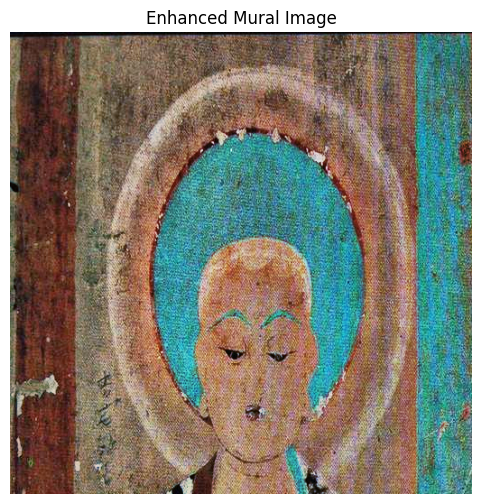

In [96]:
# Load the mural image
mural_image = cv2.imread('dataset_mural/img_16crop_0_0.png')

mural_prb = mural_image.copy()
# Apply CLAHE to enhance the image
enhanced_image = clahe_color(mural_prb, clip_limit=1.5, tile_grid_size=(8, 8))

# Display the enhanced image
mostrar_imagen("Enhanced Mural Image", enhanced_image)

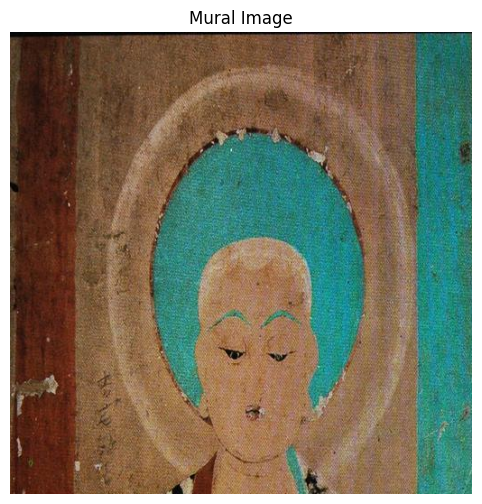

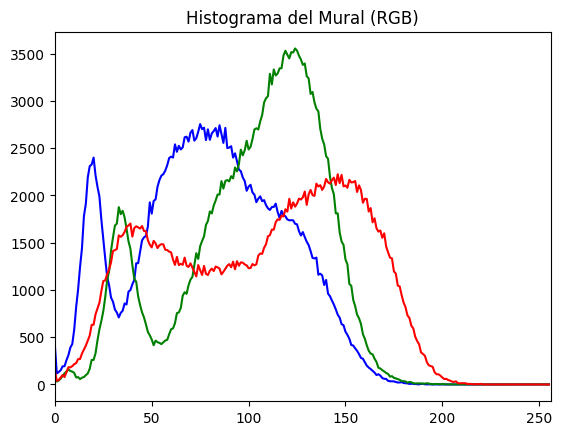

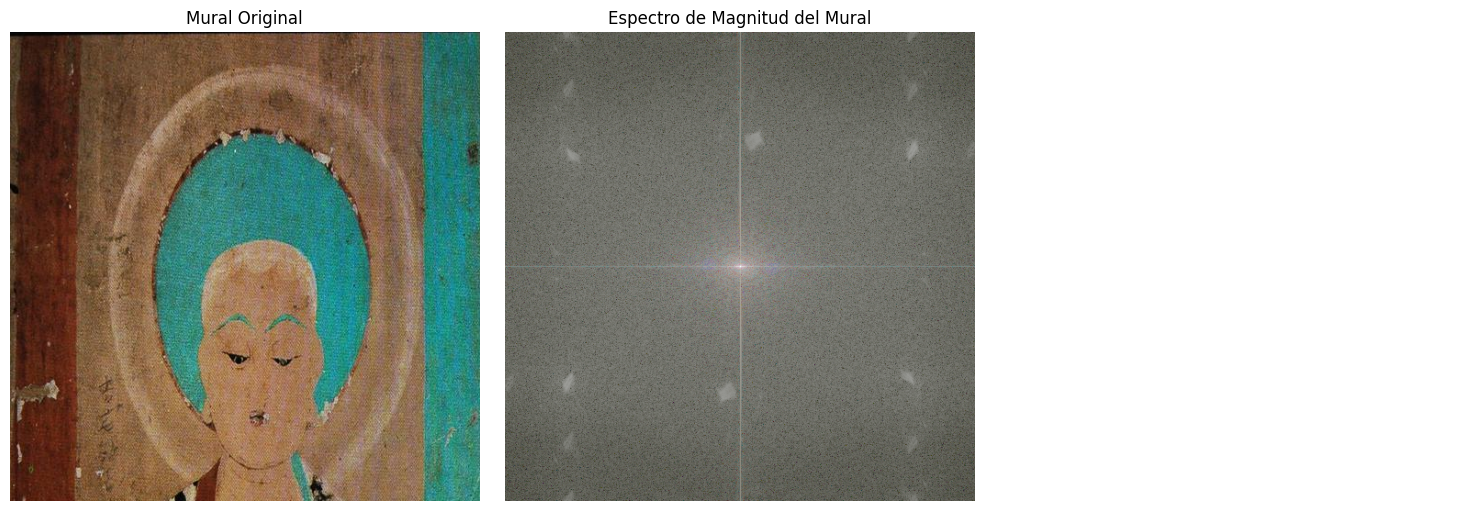

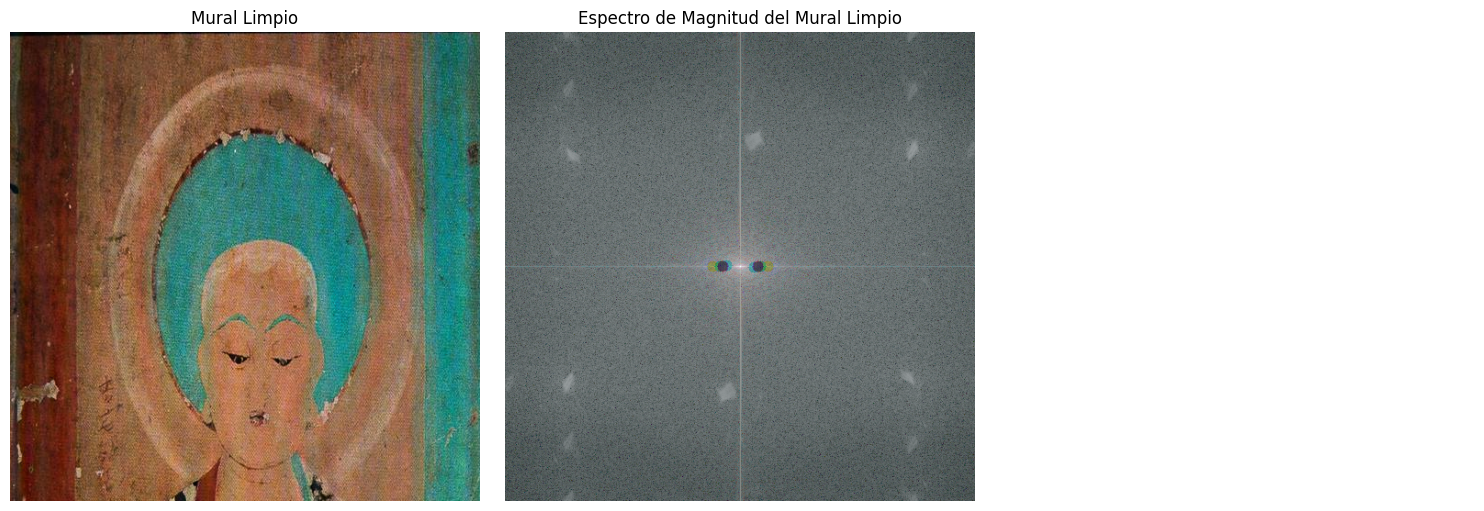

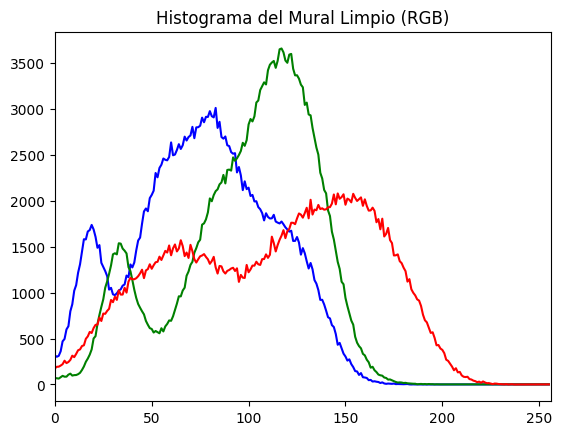

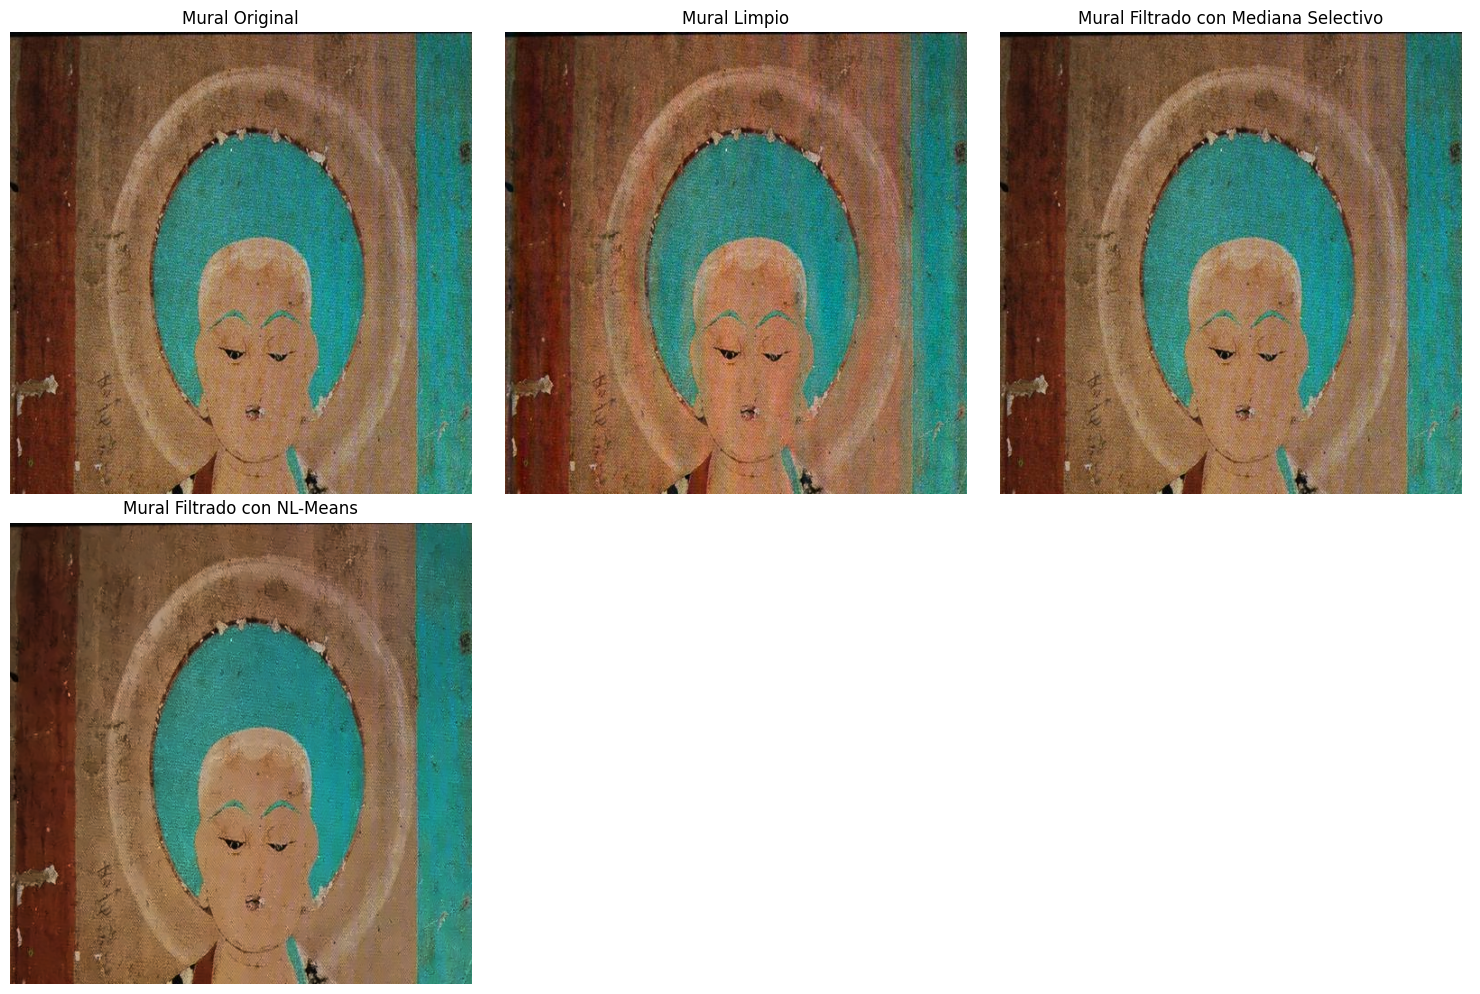

In [109]:
img_prb2 = mural_image.copy()

# Display the image to understand its condition
mostrar_imagen("Mural Image", img_prb2)

# Analizamos histograma y frecuencias
mostrar_histograma(img_prb2, "Histograma del Mural")
# Calculamos la DFT centrada
dft_shift = calcular_dft_centrada_color(img_prb2)
# Mostramos el espectro de magnitud y fase
mag_color = visualizar_magnitud_rgb(dft_shift)

show_images([mural_image, mag_color], titles=["Mural Original", "Espectro de Magnitud del Mural"])
# Aplicamos el filtro notch automático para eliminar ruido periódico
mural_limpio = eliminar_ruido_notch_automatico(img_prb2, umbral_ruido_factor=1.5, radio_notch=6, num_picos_a_eliminar_por_canal=2)
# Calculamos la DFT centrada de la imagen limpia
dft_shift_limpio = calcular_dft_centrada_color(mural_limpio)
# Mostramos el espectro de magnitud y fase de la imagen limpia
mag_color_limpio = visualizar_magnitud_rgb(dft_shift_limpio)
show_images([mural_limpio, mag_color_limpio], titles=["Mural Limpio", "Espectro de Magnitud del Mural Limpio"])
# Mostramos el histograma de la imagen limpia
mostrar_histograma(mural_limpio, "Histograma del Mural Limpio")

# Aplicamos filtro de mediana selectivo
mural_filtrado = filtro_mediana_selectivo(img_prb2, kernel_size=3)
mural_filtrado2 = filtro_non_local_means(mural_filtrado, h=4, templateWindowSize=5, searchWindowSize=15)
# Mostramos la imagen con notch, filtrada por mediana y la original
show_images([mural_image, mural_limpio, mural_filtrado, mural_filtrado2], 
            titles=["Mural Original", "Mural Limpio", "Mural Filtrado con Mediana Selectivo", "Mural Filtrado con NL-Means"])




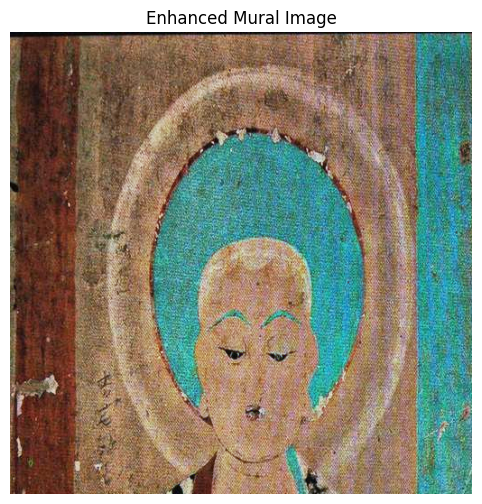

In [91]:
# Apply CLAHE to enhance the image
enhanced_image = clahe_color(mural_filtrado, clip_limit=1, tile_grid_size=(22, 22))

# Display the enhanced image
mostrar_imagen("Enhanced Mural Image", enhanced_image)

# Crack & Fissure Segmentation Pipeline for Mural Images

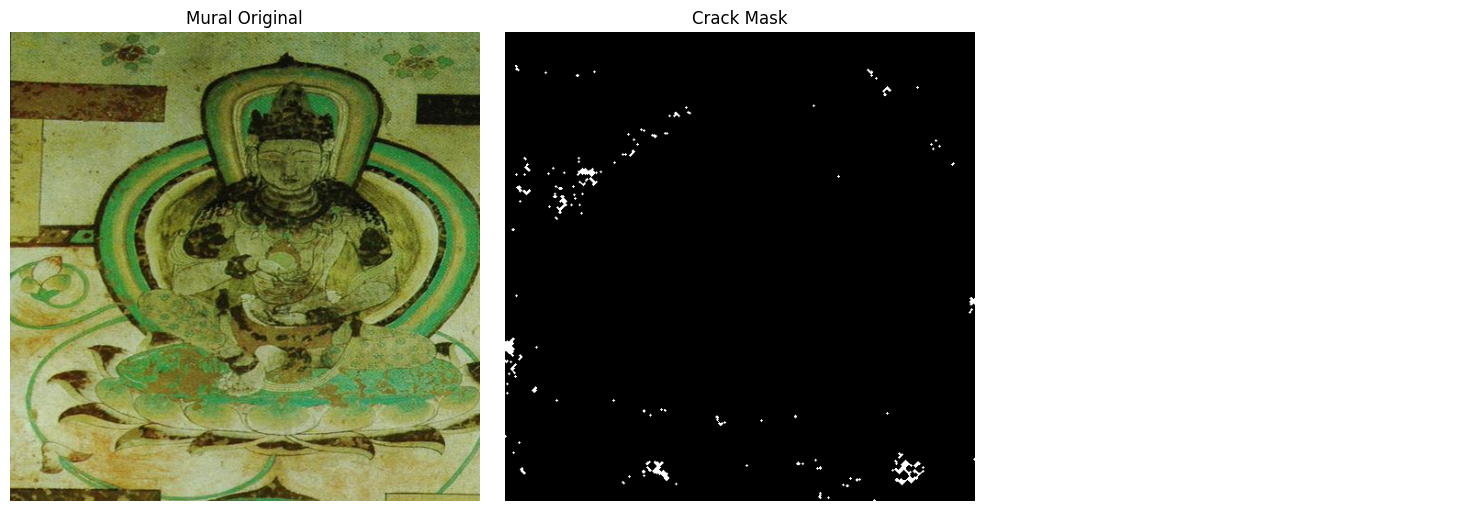

In [12]:
def test_01(img):
    # --- Preprocessing for Crack Enhancement ---

    # Convert to LAB and extract luminance
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Enhance cracks using CLAHE on luminance
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(16,16))
    l_enhanced = clahe.apply(l)

    # Merge back and convert to grayscale
    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # --- Dual-Color Thresholding ---

    # Bright cracks (white/yellowish)
    _, bright_mask = cv2.threshold(grayscale, 200, 255, cv2.THRESH_BINARY)

    # Dark cracks (brown/black)
    _, dark_mask = cv2.threshold(grayscale, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    dark_mask = cv2.bitwise_and(dark_mask, cv2.bitwise_not(bright_mask))

    # --- Color Range Isolation (Brown Cracks) ---

    # Convert to HSV for brown color detection
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Brown color range (adjust based on your murals)
    lower_brown = np.array([5, 50, 50])   # H:5-20, S:50-255, V:20-200
    upper_brown = np.array([20, 255, 200])
    brown_mask = cv2.inRange(hsv, lower_brown, upper_brown)

    # --- Texture Analysis (Line Detection) ---

    # Crack detection using line filters
    kernel_h = np.array([[-1,-1,-1], [2,2,2], [-1,-1,-1]])  # Horizontal
    kernel_v = np.array([[-1,2,-1], [-1,2,-1], [-1,2,-1]])   # Vertical

    horizontal = cv2.filter2D(grayscale, -1, kernel_h)
    vertical = cv2.filter2D(grayscale, -1, kernel_v)
    line_mask = cv2.add(horizontal, vertical)

    # Threshold line responses
    _, line_mask = cv2.threshold(line_mask, 40, 255, cv2.THRESH_BINARY)

    # --- Mask Fusion & Refinement ---

    # Combine all masks
    combined = cv2.bitwise_or(bright_mask, dark_mask)
    combined = cv2.bitwise_or(combined, brown_mask)
    combined = cv2.bitwise_or(combined, line_mask)

    # Morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    cleaned = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel, iterations=1)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Remove small noise
    final_mask = cv2.connectedComponentsWithStats(cleaned)[1]
    final_mask = np.uint8(np.where(final_mask > 1, 255, 0))

    return final_mask

# Visual calibration tool
def update_brown_mask(x):
    lower_brown = np.array([cv2.getTrackbarPos('H1','calib'), 
                          cv2.getTrackbarPos('S1','calib'),
                          cv2.getTrackbarPos('V1','calib')])
    upper_brown = np.array([cv2.getTrackbarPos('H2','calib'), 
                          cv2.getTrackbarPos('S2','calib'),
                          cv2.getTrackbarPos('V2','calib')])
    mask = cv2.inRange(hsv, lower_brown, upper_brown)
    cv2.imshow('calib', mask)

img = cv2.imread('dataset_mural/img_1066crop_0_0.png')
crack_mask = test_01(img)


show_images([img, crack_mask], titles=["Mural Original", "Crack Mask"])